# Hospitality Forecasting System: Portfolio Walkthrough

## Project Summary
This project develops an end-to-end forecasting pipeline for hospitality operations using anonymised operational data.

The system:
- preprocesses raw rota-style exports
- builds daily sales and labour datasets
- engineers time-series, holiday, payday, and weather features
- benchmarks human forecasts and classical baselines
- trains SARIMAX and XGBoost models
- evaluates forecasting accuracy and business implications

The final objective is not just predictive accuracy, but improving operational decision-making in a hospitality setting.

> **Note:** This notebook is committed pre-executed, with real output already saved in each cell, so the results are visible without running anything. If you want fresh or updated metrics (e.g. after retraining a model or re-running the pipeline), just re-run all cells.


## 1. Business Problem

Hospitality operations rely heavily on daily demand forecasting for:
- staffing
- labour planning
- wage control
- operational efficiency

In this project, I investigated whether machine learning and time-series methods could improve on manual forecasts and reduce downstream inefficiencies.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..")
sales_path = PROJECT_ROOT / "data" / "processed" / "sales" / "daily_sales_totals_master.csv"
labour_path = PROJECT_ROOT / "data" / "processed" / "labour" / "daily_labour_totals_master.csv"

sales = pd.read_csv(sales_path)
labour = pd.read_csv(labour_path)

sales.head()

,date,department,total_sales,forecast_sales,source_file
0,2024-01-02,FOH,7082.3332,8100.0,Rotaready-CostControlRawData01_sales.csv
1,2024-01-03,FOH,7958.0918,7300.0,Rotaready-CostControlRawData01_sales.csv
2,2024-01-04,FOH,7620.8835,6700.0,Rotaready-CostControlRawData01_sales.csv
3,2024-01-05,FOH,9673.2500,7700.0,Rotaready-CostControlRawData01_sales.csv
4,2024-01-06,FOH,12043.1501,10700.0,Rotaready-CostControlRawData01_sales.csv


## 2. Processed Data

The project uses daily aggregated data derived from anonymised weekly operational files.

Key fields include:
- total realised sales
- manual forecasted sales
- realised labour hours and wages
- forecasted labour hours and wages

In [2]:
sales["date"] = pd.to_datetime(sales["date"])
labour["date"] = pd.to_datetime(labour["date"])

print("Sales shape:", sales.shape)
print("Labour shape:", labour.shape)
print("Sales date range:", sales["date"].min(), "to", sales["date"].max())

Sales shape: (734, 5)
Labour shape: (735, 7)
Sales date range: 2024-01-02 00:00:00 to 2026-01-04 00:00:00


## 3. Feature Engineering

A broad feature set was engineered, including:
- calendar features
- cyclical encodings
- lagged sales features
- bank holiday proximity
- payday effects
- school holiday flags
- weather-derived indicators

A narrower subset was selected for the final XGBoost model.

In [3]:
features_path = PROJECT_ROOT / "data" / "features" / "engineered_features.csv"
model_features_path = PROJECT_ROOT / "data" / "features" / "model_features.csv"

engineered = pd.read_csv(features_path)
model_df = pd.read_csv(model_features_path)

print("Engineered feature columns:", len(engineered.columns))
print("Final model feature columns:", len(model_df.columns))
model_df.head()

Engineered feature columns: 46
Final model feature columns: 17


,date,total_sales,forecast_sales,month_sin,day_of_week,day_of_year_cos,day_of_year_sin,day_of_year,month_cos,month,day_of_week_sin,is_bank_holiday,days_to_bank_holiday,days_since_payday,is_payday_window_pm3,is_long_weekend,is_heavy_rain
0,2024-01-02,7082.3332,8100.0,0.0,1,0.999852,0.017213,2,1.0,1,0.000000,1,0,4,0,0,1
1,2024-01-03,7958.0918,7300.0,0.0,2,0.999407,0.034422,3,1.0,1,0.781831,0,86,5,0,0,0
2,2024-01-04,7620.8835,6700.0,0.0,3,0.998667,0.051620,4,1.0,1,0.974928,0,85,6,0,0,0
3,2024-01-05,9673.2500,7700.0,0.0,4,0.997630,0.068802,5,1.0,1,0.433884,0,84,7,0,0,0
4,2024-01-06,12043.1501,10700.0,0.0,5,0.996298,0.085965,6,1.0,1,-0.433884,0,83,8,0,0,0


## 4. Baselines

Before training advanced models, simple benchmarks were evaluated:
- naive
- seasonal naive
- rolling 7-day mean
- rolling 14-day mean
- rolling 28-day mean
- weekday average baseline

This establishes whether more advanced models are genuinely adding value.

In [4]:
baseline_metrics_path = PROJECT_ROOT / "reports" / "results" / "baseline_metrics.csv"
baseline_metrics = pd.read_csv(baseline_metrics_path)
baseline_metrics

,model,n,MAE,RMSE,MAPE
0,naive,428.0,3082.344609,4006.141418,36.117404
1,seasonal_naive,428.0,1386.335326,2043.028420,18.034897
2,roll7,422.0,2875.644520,3609.988708,34.245629
3,roll14,415.0,2867.514985,3635.083992,34.183040
4,roll28,401.0,2922.637802,3724.568305,35.514580
5,weekday_average,429.0,1554.497352,2179.522180,17.408135


## 5. Human Forecast Benchmark

A major strength of this project is that model performance was not only compared to simple statistical baselines, but also to real manual forecasts.

This makes the evaluation more operationally meaningful.

In [5]:
human_metrics_all = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "human_forecast_metrics_all.csv")
human_metrics_2025 = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "human_forecast_metrics_2025.csv")

human_metrics_all

,dataset,Average daily sales (£),MAE,RMSE,MAPE (%),Bias (£),Total overforecasted wages (£),Total underforecasted wages (£),Total overforecasted sales (£),£ wasted per £1 overforecasted sales,Overstaffed days,Understaffed days,Average wasted wages on overstaffed days (£),Wage bias (£)
0,whole_dataset,8610.64,1073.79,1376.39,14.12,152.27,108973.34,27806.02,446896.83,0.2438,520,209,209.56,111.34


## 6. SARIMAX Benchmark

A SARIMAX model was trained as a classical time-series benchmark using a small exogenous feature set.

This served as an interpretable statistical reference before the final machine learning model.

In [6]:
sarimax_metrics = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "sarimax_metrics.csv")
sarimax_metrics

,model,order,seasonal_order,exog_features,MAE,RMSE,MAPE
0,sarimax,"(1, 1, 1)","(0, 1, 1, 7)","forecast_sales, lag_7_sales",2904.225935,3785.140269,39.217477


## 7. Final XGBoost Model

The final model used the selected feature subset and was trained using a time-based split.

The selected features combined:
- manual forecast input
- cyclical seasonality
- calendar and holiday context
- payday effects
- weather signal

In [7]:
xgb_metrics = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "xgboost_metrics.csv")
xgb_metrics

,model,MAE,RMSE,MAPE,Bias
0,xgboost,1038.554383,1351.959603,13.226478,38.640012


## 8. Visual Forecast Comparison

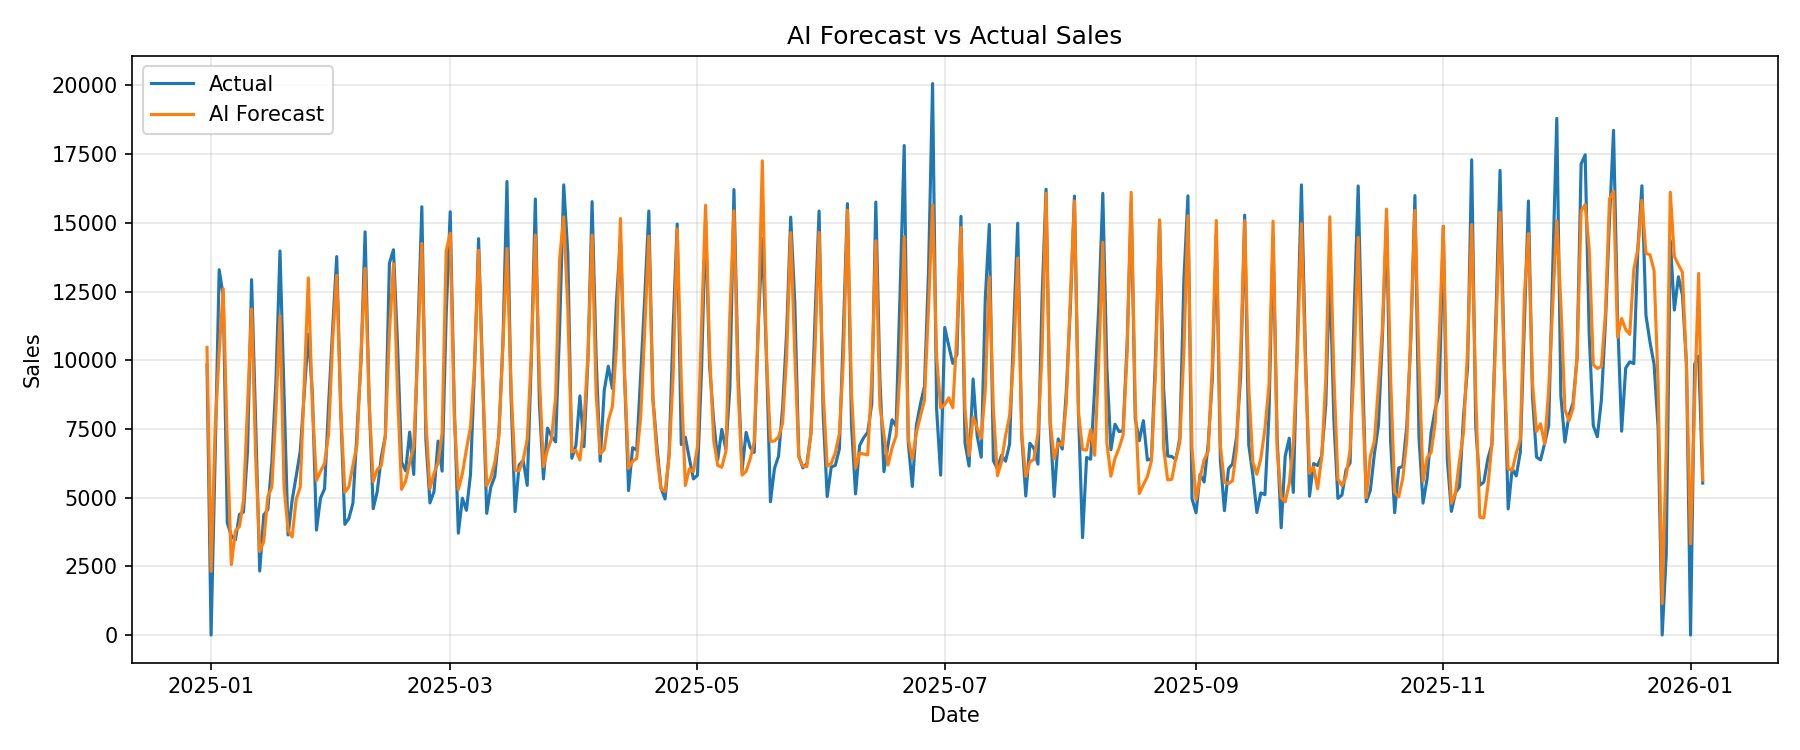

In [8]:
from IPython.display import Image

Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "xgboost_forecast_vs_actual.png"))

## 9. Best 8-Week Window

To make results easier to communicate, I also identified the strongest 8-week period where the AI forecast tracked real demand more closely than the manual forecast.

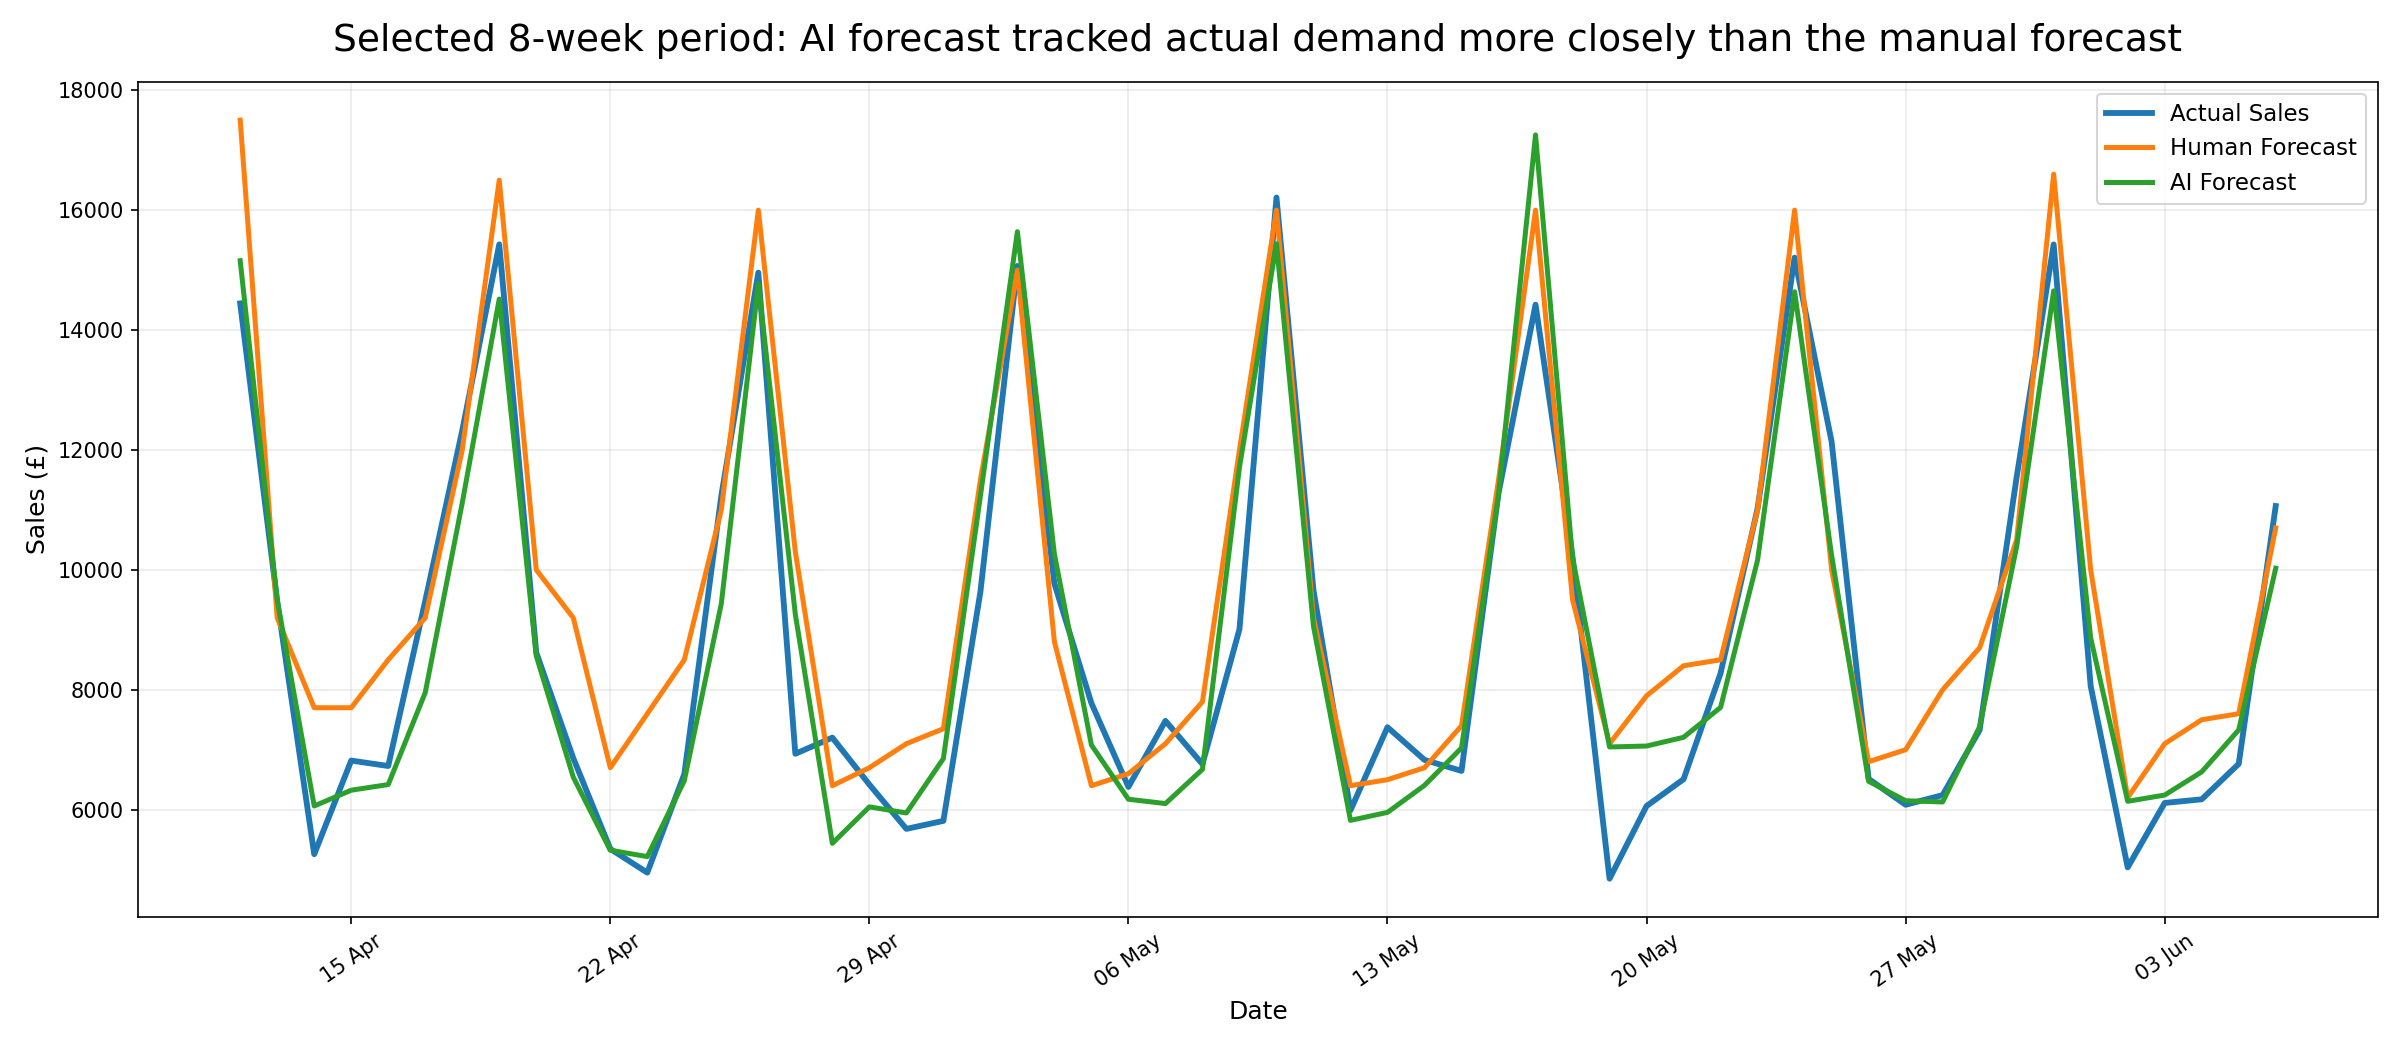

In [9]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "best_8_week_window.png"))

## 10. Error Analysis

Error analysis was used to identify:
- worst forecast days
- overprediction-heavy periods
- underprediction-heavy periods
- possible regime changes and drift

This was especially important when performance degraded on newer validation periods.

In [10]:
xgb_predictions = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "xgboost_predictions.csv")
xgb_predictions.head()

,date,total_sales,forecast_sales,ai_prediction
0,2024-12-31,9828.6665,9700.0,10465.5030
1,2025-01-01,0.0000,0.0,2316.9072
2,2025-01-02,6459.5834,7100.0,7514.8080
3,2025-01-03,13292.6251,9600.0,10292.1570
4,2025-01-04,12346.4581,12100.0,12602.1030


## 11. Neural Forecasters & Formal Model Comparison

Beyond the XGBoost/SARIMAX comparison above, I trained two neural sequence models - an LSTM and a small Transformer (PyTorch) - as a genuinely different model family: instead of one row of hand-engineered features per day, these read a 30-day window of recent history directly and learn temporal patterns themselves.

Every model in this project (6 baselines, SARIMAX, XGBoost, LSTM, Transformer) is tracked in a public [Weights & Biases dashboard](https://wandb.ai/kevin-pino-arias-three-body/hospitality-forecasting), including hyperparameters, metrics, and a multi-seed robustness check for the two neural models.

The comparison below goes beyond a single aggregate MAE per model - it asks *what wins, where, and why*, using the same date range for every model so the comparison is genuinely fair.


In [11]:
comparison_overall = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "model_comparison_overall.csv")
comparison_overall


,model,MAE,RMSE,MAPE,Bias,n
0,xgboost,1049.942996,1373.079037,13.238273,43.890338,339
1,transformer,1280.833367,1849.457843,15.728176,106.809230,339
2,seasonal_naive,1353.241634,1999.809438,18.469847,41.562587,339
3,lstm,1357.346077,1886.735268,16.194823,-144.282844,339
4,weekday_average,1419.010224,1982.096891,16.582773,-610.256748,339
5,roll7,2877.242231,3621.234736,34.933179,77.173308,339
6,roll14,2884.310581,3650.093326,35.363025,116.476077,339
7,roll28,2942.730999,3731.408174,36.956681,176.205608,339
8,sarimax,3080.697059,3977.416902,42.516296,885.718107,339
9,naive,3153.286560,4114.978620,37.272731,22.005113,339


### Overall MAE vs. who wins the most individual days

These are different questions. A model can have the best *average* error while rarely being the single closest guess on any given day - and vice versa.


In [12]:
win_counts = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "model_comparison_win_counts.csv")
win_counts


,model,wins,win_pct
0,seasonal_naive,71,20.9
1,xgboost,64,18.9
2,transformer,47,13.9
3,weekday_average,42,12.4
4,lstm,39,11.5
5,naive,27,8.0
6,roll7,14,4.1
7,roll28,13,3.8
8,sarimax,13,3.8
9,roll14,9,2.7


### Spike days specifically

The error analysis earlier in this notebook found that the hardest days to forecast - unusually strong peaks - are where forecasting value matters most. This breaks every model's error out by whether a day was flagged as a spike (top 10% of actual sales in the comparison window) or a normal day.


In [13]:
spike_comparison = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "model_comparison_spike_vs_normal.csv")
spike_comparison.sort_values(["is_spike_day", "mean_absolute_error"])


,model,is_spike_day,mean_absolute_error,mean_signed_error,median_absolute_error,n
15,xgboost,False,1023.738857,178.447373,809.821100,305
19,transformer,False,1243.175142,281.945907,992.839500,305
17,lstm,False,1289.740210,35.306404,922.891700,305
11,weekday_average,False,1323.789346,-424.879746,898.680858,305
2,seasonal_naive,False,1359.071854,93.317054,995.016500,305
7,roll14,False,2389.246200,946.054381,2216.145921,305
5,roll7,False,2398.776913,884.983308,2214.439157,305
9,roll28,False,2435.939781,1030.681562,2214.548418,305
13,sarimax,False,2811.265820,1597.307102,2066.713949,305
1,naive,False,2965.501618,563.756995,2167.541700,305


### Business impact (implied wages)

None of these models predict wages or staffing directly, only sales - so to compare them on business terms (in the same spirit as the labour-cost metrics computed for the manual forecast earlier), each model's predicted sales is converted to an *implied* wage forecast using the training-period wage-to-sales ratio. This is a stated approximation for comparison purposes, not a measured relationship - actual staffing decisions aren't purely proportional to sales.


In [14]:
business_impact = pd.read_csv(PROJECT_ROOT / "reports" / "results" / "model_comparison_business_impact.csv")
business_impact


,model,implied total overforecasted wages (£),implied total underforecasted wages (£),implied overstaffed days,implied understaffed days
0,weekday_average,43537.28,109240.66,122,217
1,xgboost,58883.86,54158.40,167,172
2,lstm,65302.31,80836.55,165,174
3,transformer,74700.37,63200.74,175,164
4,seasonal_naive,75085.90,70611.06,156,181
5,roll7,159043.79,150734.91,214,125
6,roll14,161540.06,148999.65,216,123
7,roll28,167900.38,148929.18,210,129
8,naive,170934.12,168564.93,144,195
9,sarimax,213522.33,118161.36,215,124


### What this comparison actually found

- **XGBoost has the best overall MAE**, and also wins outright on spike days specifically - the hardest, most operationally important days.
- **`seasonal_naive` ("same weekday last week") wins the most individual days** despite not having the best average error - a sign that hospitality demand has strong, direct weekly recurrence that a simple lookup captures well, even against more complex models.
- **Neither neural model beats XGBoost**, though the Transformer consistently outperforms the LSTM and comes close to the strong baselines - a genuinely useful, honest finding rather than a disappointment: it shows the added complexity of a neural sequence model isn't yet clearly earning its keep on a dataset this size, which is a real and common outcome for small tabular/time-series problems, not a failure of the approach.
- **A real data-quality bug was found and fixed while building this comparison**: the raw exports had no row at all for Christmas Day and New Year's Day (confirmed closures, not missing data), which - combined with the neural models' window-based training - was silently excluding the first two months of the validation period from ever being fairly compared. Fixing it at the source (rather than working around it) changed the comparison window from 304 days to the full 339-day validation period, and shifted several of the findings above. Left as a reminder that a "formal evaluation framework" is only as trustworthy as the data underneath it.


## 12. Key Takeaways

### Technical
- Built a modular end-to-end forecasting pipeline
- Compared multiple model families
- Engineered domain-specific time-series features
- Used business-aware evaluation, not just predictive metrics

### Operational
- Machine learning outperformed simple baselines
- Comparison against human forecasts made results decision-relevant
- Validation on later periods highlighted drift and the need for adaptive retraining

### Portfolio value
This project demonstrates not just model training, but full workflow design, evaluation discipline, and business-oriented thinking.